In [10]:
from typing import Annotated

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict
from langchain_core.messages import BaseMessage
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

In [11]:
load_dotenv()

True

In [12]:
# model = HuggingFaceEndpoint(
#     repo_id="mistralai/Mistral-7B-Instruct-v0.2",
#     task="text-generation"
# )

# llm = ChatHuggingFace(llm=model)

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

## Sub Graph

In [13]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [14]:
def translate_text(state: ParentState):

    prompt = f"""
    Translate the following text to hindi.
    Keep it natural and clear. Do not add extra content.

    Text: {state['answer_eng']}

""".strip()

    translated_text = llm.invoke(prompt).content

    return {'answer_hin': translated_text}


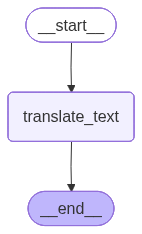

In [15]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text',translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()
subgraph

## Parent Graph

In [16]:
def generate_answer(state: ParentState):

    answer = llm.invoke(f"You are a helpful assistant. Answer the question: {state['question']}").content

    return {'answer_eng': answer}

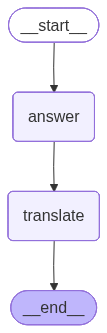

In [17]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node('answer',generate_answer)
parent_builder.add_node('translate',subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

parent_graph = parent_builder.compile()
parent_graph

In [18]:
parent_graph.invoke({'question':'What is the quantum physics?'})

{'question': 'What is the quantum physics?',
 'answer_eng': 'Quantum physics (also known as quantum mechanics or quantum theory) is a fundamental branch of physics that describes the behavior of matter and energy at the smallest scales: atoms, subatomic particles (like electrons and protons), and light.\n\nIt\'s a radical departure from classical physics (the physics we experience in our everyday world) because it reveals a universe that operates on very different, often counter-intuitive, rules when you zoom in close enough.\n\nHere are the core concepts that define quantum physics:\n\n1.  **Quantization:** The word "quantum" itself means a discrete, indivisible unit. In the quantum world, certain physical properties, like energy, momentum, and spin, don\'t exist on a continuous spectrum (like a ramp) but rather in discrete "packets" or "steps" (like a staircase). For example, an electron in an atom can only have specific energy levels, not just any energy level.\n\n2.  **Wave-Particl